# Análise de Evasão Escolar no Brasil

## 1. Introdução ao Problema

A evasão escolar é um desafio significativo no sistema educacional brasileiro, impactando o desenvolvimento individual dos alunos e o progresso social e econômico do país. Este notebook tem como objetivo analisar um conjunto de dados simulado sobre evasão escolar no Brasil para identificar padrões, fatores contribuintes e propor insights que possam auxiliar na formulação de estratégias de retenção de alunos. Através da análise exploratória de dados, engenharia de atributos e identificação de KPIs, buscaremos compreender melhor a dinâmica da evasão e seus impactos.

## 2. Explicação da Base de Dados

O dataset `simulacao_evasao_escolar_brasil.csv` contém dados simulados relacionados à evasão escolar no Brasil. Embora seja uma simulação, ele foi projetado para refletir características e fatores comuns associados à evasão. As colunas esperadas neste dataset incluem informações sobre o aluno, o contexto educacional e indicadores de desempenho. Uma análise detalhada das colunas será realizada após o carregamento dos dados.

## 3. Leitura dos Dados

In [1]:
import pandas as pd

# Carregar o dataset
try:
    df = pd.read_csv('/content/simulacao_evasao_escolar_brasil.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'simulacao_evasao_escolar_brasil.csv' não foi encontrado. Verifique o caminho do arquivo.")
    df = pd.DataFrame() # Cria um DataFrame vazio para evitar erros posteriores

# Exibir as primeiras linhas do DataFrame e informações básicas
if not df.empty:
    print("\nPrimeiras 5 linhas do dataset:")
    display(df.head())
    print("\nInformações gerais do dataset:")
    df.info()
else:
    print("Nenhum dado para exibir pois o DataFrame está vazio.")

Dataset carregado com sucesso!

Primeiras 5 linhas do dataset:


,ano,semestre,data,regiao,uf,municipio,rede_ensino,serie,matriculados,evasoes,taxa_evasao,renda_media_familiar,indice_desempenho,acesso_internet,nivel_risco
0,2015,1,2015-06-01,Norte,AM,Manaus,Pública,3º ano,38388,3604,9.39,3302.32,66.53,87.5,Alto
1,2015,1,2015-06-01,Norte,AM,Manaus,Privada,3º ano,34326,979,2.85,2323.55,85.59,64.6,Baixo
2,2015,1,2015-06-01,Norte,PA,Belém,Pública,1º ano,22029,2461,11.18,2728.75,80.67,82.6,Alto
3,2015,1,2015-06-01,Norte,PA,Belém,Privada,2º ano,45187,1483,3.28,4389.77,68.68,61.8,Baixo
4,2015,1,2015-06-01,Norte,PA,Santarém,Pública,3º ano,37786,4071,10.77,2100.56,36.26,73.0,Alto



Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   1480 non-null   int64  
 1   semestre              1480 non-null   int64  
 2   data                  1480 non-null   object 
 3   regiao                1480 non-null   object 
 4   uf                    1480 non-null   object 
 5   municipio             1480 non-null   object 
 6   rede_ensino           1480 non-null   object 
 7   serie                 1480 non-null   object 
 8   matriculados          1480 non-null   int64  
 9   evasoes               1480 non-null   int64  
 10  taxa_evasao           1480 non-null   float64
 11  renda_media_familiar  1480 non-null   float64
 12  indice_desempenho     1480 non-null   float64
 13  acesso_internet       1480 non-null   float64
 14  nivel_risco           1480 non-null   ob

## 4. Limpeza e Preparação dos Dados

In [2]:
# Convertendo a coluna 'data' para o tipo datetime
df['data'] = pd.to_datetime(df['data'])
print("Coluna 'data' convertida para datetime.")

# Verificando valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Verificando e tratando duplicatas, se houver
if df.duplicated().any():
    print("\nDuplicatas encontradas. Removendo...")
    df.drop_duplicates(inplace=True)
    print("Duplicatas removidas.")
else:
    print("\nNenhuma duplicata encontrada.")

# Exibir informações atualizadas do DataFrame
print("\nInformações gerais do dataset após limpeza:")
df.info()

Coluna 'data' convertida para datetime.

Valores ausentes por coluna:
ano                     0
semestre                0
data                    0
regiao                  0
uf                      0
municipio               0
rede_ensino             0
serie                   0
matriculados            0
evasoes                 0
taxa_evasao             0
renda_media_familiar    0
indice_desempenho       0
acesso_internet         0
nivel_risco             0
dtype: int64

Nenhuma duplicata encontrada.

Informações gerais do dataset após limpeza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ano                   1480 non-null   int64         
 1   semestre              1480 non-null   int64         
 2   data                  1480 non-null   datetime64[ns]
 3   regiao                1480 non-null   object     

## 5. Engenharia de Atributos

In [3]:
# Extrair o mês e trimestre da coluna 'data'
df['mes'] = df['data'].dt.month
df['trimestre'] = df['data'].dt.quarter
print("Colunas 'mes' e 'trimestre' criadas a partir da coluna 'data'.")

# Criar uma feature de interação: Renda por Indice de Desempenho (exemplo)
# Esta feature pode ajudar a entender como o desempenho escolar se relaciona com a renda em termos de evasão
df['renda_x_desempenho'] = df['renda_media_familiar'] * df['indice_desempenho']
print("Coluna 'renda_x_desempenho' criada.")

# Criar uma feature binária para 'Alto Risco' com base na coluna 'nivel_risco'
df['is_alto_risco'] = df['nivel_risco'].apply(lambda x: 1 if x == 'Alto' else 0)
print("Coluna 'is_alto_risco' (binária) criada.")

# Exibir as primeiras linhas com as novas features
print("\nPrimeiras 5 linhas do dataset com as novas features:")
display(df.head())

# Exibir informações atualizadas do DataFrame para ver as novas colunas
print("\nInformações gerais do dataset após engenharia de atributos:")
df.info()

Colunas 'mes' e 'trimestre' criadas a partir da coluna 'data'.
Coluna 'renda_x_desempenho' criada.
Coluna 'is_alto_risco' (binária) criada.

Primeiras 5 linhas do dataset com as novas features:


,ano,semestre,data,regiao,uf,municipio,rede_ensino,serie,matriculados,evasoes,taxa_evasao,renda_media_familiar,indice_desempenho,acesso_internet,nivel_risco,mes,trimestre,renda_x_desempenho,is_alto_risco
0,2015,1,2015-06-01,Norte,AM,Manaus,Pública,3º ano,38388,3604,9.39,3302.32,66.53,87.5,Alto,6,2,219703.3496,1
1,2015,1,2015-06-01,Norte,AM,Manaus,Privada,3º ano,34326,979,2.85,2323.55,85.59,64.6,Baixo,6,2,198872.6445,0
2,2015,1,2015-06-01,Norte,PA,Belém,Pública,1º ano,22029,2461,11.18,2728.75,80.67,82.6,Alto,6,2,220128.2625,1
3,2015,1,2015-06-01,Norte,PA,Belém,Privada,2º ano,45187,1483,3.28,4389.77,68.68,61.8,Baixo,6,2,301489.4036,0
4,2015,1,2015-06-01,Norte,PA,Santarém,Pública,3º ano,37786,4071,10.77,2100.56,36.26,73.0,Alto,6,2,76166.3056,1



Informações gerais do dataset após engenharia de atributos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ano                   1480 non-null   int64         
 1   semestre              1480 non-null   int64         
 2   data                  1480 non-null   datetime64[ns]
 3   regiao                1480 non-null   object        
 4   uf                    1480 non-null   object        
 5   municipio             1480 non-null   object        
 6   rede_ensino           1480 non-null   object        
 7   serie                 1480 non-null   object        
 8   matriculados          1480 non-null   int64         
 9   evasoes               1480 non-null   int64         
 10  taxa_evasao           1480 non-null   float64       
 11  renda_media_familiar  1480 non-null   float64       
 12  indice_desempen

## 6. Análise Exploratória de Dados (EDA)


Estatísticas descritivas das colunas numéricas:


,ano,semestre,data,matriculados,evasoes,taxa_evasao,renda_media_familiar,indice_desempenho,acesso_internet,mes,trimestre,renda_x_desempenho,is_alto_risco
count,1480.000000,1480.000000,1480,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000
mean,2019.500000,1.500000,2020-03-01 11:59:59.999999744,25564.539189,1850.203378,7.262797,2807.680101,64.724716,69.750811,9.000000,3.000000,181324.085952,0.400676
min,2015.000000,1.000000,2015-06-01 00:00:00,393.000000,3.000000,0.500000,462.350000,32.720000,45.100000,6.000000,2.000000,19682.239500,0.000000
25%,2017.000000,1.000000,2017-10-16 06:00:00,12961.750000,648.250000,4.160000,2358.022500,56.645000,56.900000,6.000000,2.000000,143112.443775,0.000000
50%,2019.500000,1.500000,2020-03-01 12:00:00,26093.500000,1474.500000,7.315000,2822.595000,64.525000,69.950000,9.000000,3.000000,179368.609250,0.000000
75%,2022.000000,2.000000,2022-07-16 18:00:00,37807.250000,2763.750000,10.410000,3275.555000,72.490000,82.125000,12.000000,4.000000,217590.514375,1.000000
max,2024.000000,2.000000,2024-12-01 00:00:00,49989.000000,6943.000000,16.310000,4618.800000,102.220000,94.900000,12.000000,4.000000,438324.120000,1.000000
std,2.873252,0.500169,NaN,14300.333835,1485.759240,3.716492,673.741221,11.876051,14.510456,3.001014,1.000338,53944.601691,0.490201


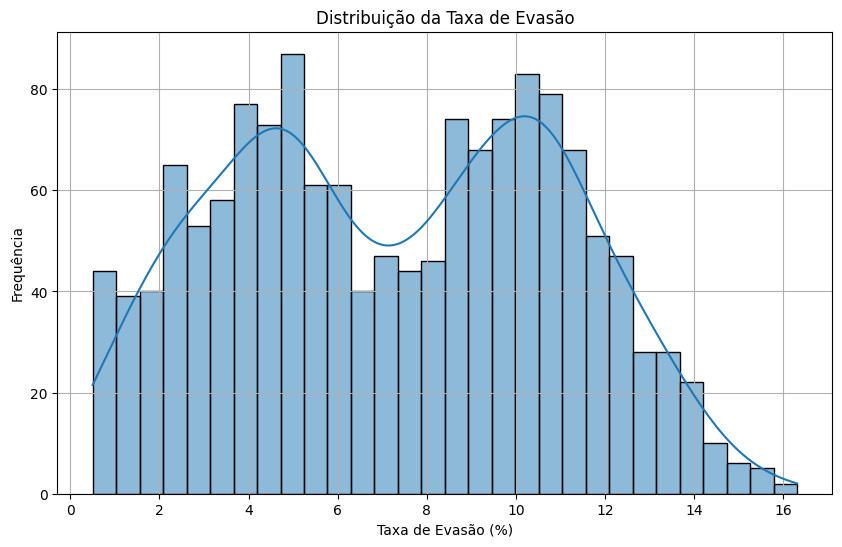


Matriz de Correlação entre variáveis numéricas:


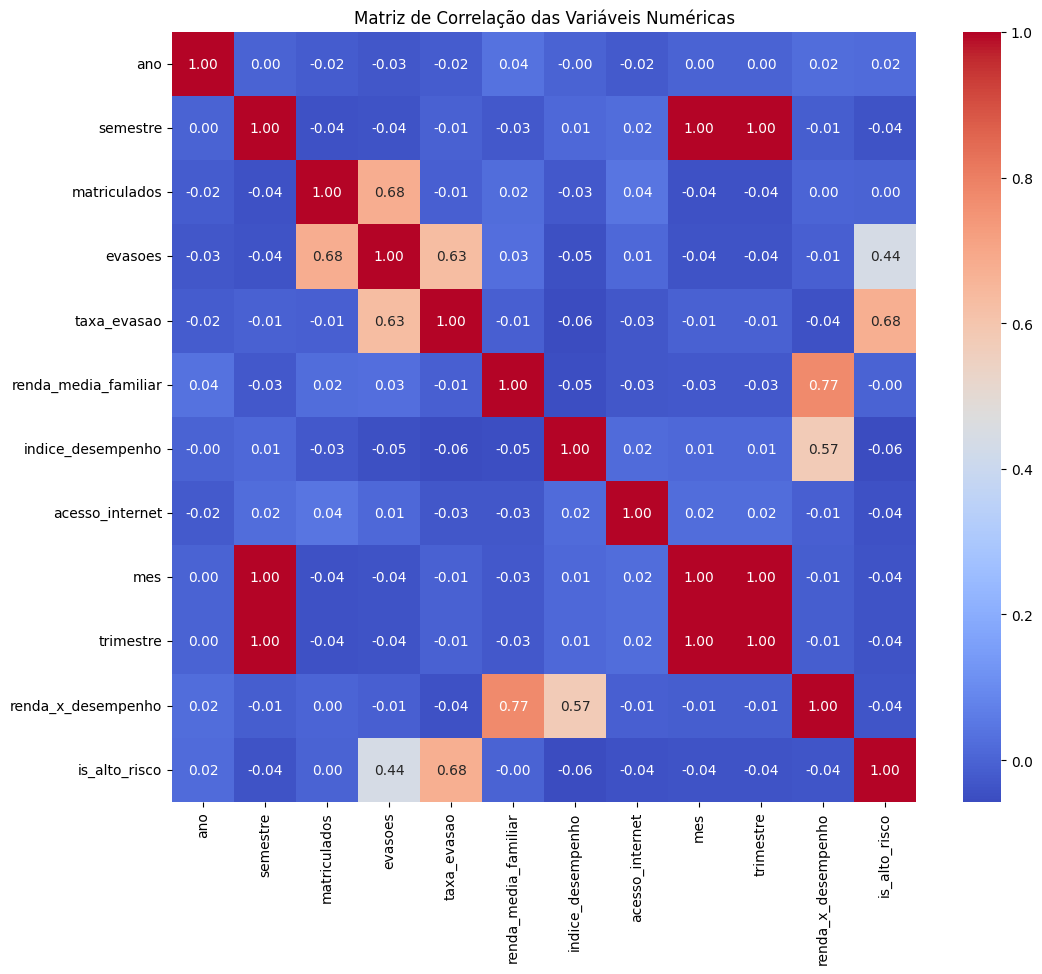

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exibir estatísticas descritivas para as colunas numéricas
print("\nEstatísticas descritivas das colunas numéricas:")
display(df.describe())

# Distribuição da Taxa de Evasão
plt.figure(figsize=(10, 6))
sns.histplot(df['taxa_evasao'], bins=30, kde=True)
plt.title('Distribuição da Taxa de Evasão')
plt.xlabel('Taxa de Evasão (%)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# Análise de correlação entre variáveis numéricas
print("\nMatriz de Correlação entre variáveis numéricas:")
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64', 'int32']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()


## 7. KPIs (Key Performance Indicators)

In [5]:
# KPI 1: Taxa Média de Evasão Geral
kpi_media_evasao = df['taxa_evasao'].mean()
print(f"KPI 1: Taxa Média de Evasão Geral: {kpi_media_evasao:.2f}%")

# KPI 2: Taxa de Evasão por Rede de Ensino
kpi_evasao_rede = df.groupby('rede_ensino')['taxa_evasao'].mean().reset_index()
kpi_evasao_rede.columns = ['Rede de Ensino', 'Taxa Média de Evasão']
print("\nKPI 2: Taxa Média de Evasão por Rede de Ensino:")
display(kpi_evasao_rede)

# KPI 3: Taxa de Evasão por Região
kpi_evasao_regiao = df.groupby('regiao')['taxa_evasao'].mean().reset_index()
kpi_evasao_regiao.columns = ['Região', 'Taxa Média de Evasão']
print("\nKPI 3: Taxa Média de Evasão por Região:")
display(kpi_evasao_regiao)

# KPI 4: Ano com maior e menor taxa de evasão média
kpi_evasao_ano = df.groupby('ano')['taxa_evasao'].mean().reset_index()
ano_maior_evasao = kpi_evasao_ano.loc[kpi_evasao_ano['taxa_evasao'].idxmax()]
ano_menor_evasao = kpi_evasao_ano.loc[kpi_evasao_ano['taxa_evasao'].idxmin()]
print(f"\nKPI 4: Ano com maior taxa de evasão média: {int(ano_maior_evasao['ano'])} com {ano_maior_evasao['taxa_evasao']:.2f}%")
print(f"KPI 4: Ano com menor taxa de evasão média: {int(ano_menor_evasao['ano'])} com {ano_menor_evasao['taxa_evasao']:.2f}%")

KPI 1: Taxa Média de Evasão Geral: 7.26%

KPI 2: Taxa Média de Evasão por Rede de Ensino:


,Rede de Ensino,Taxa Média de Evasão
0,Privada,4.128568
1,Pública,10.397027



KPI 3: Taxa Média de Evasão por Região:


,Região,Taxa Média de Evasão
0,Centro-Oeste,7.340350
1,Nordeste,7.311125
2,Norte,6.976150
3,Sudeste,7.364038
4,Sul,7.153250



KPI 4: Ano com maior taxa de evasão média: 2016 com 7.46%
KPI 4: Ano com menor taxa de evasão média: 2019 com 7.16%


## 8. Gráficos

/tmp/ipykernel_2044/1820826798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rede de Ensino', y='Taxa Média de Evasão', data=kpi_evasao_rede, palette='viridis')


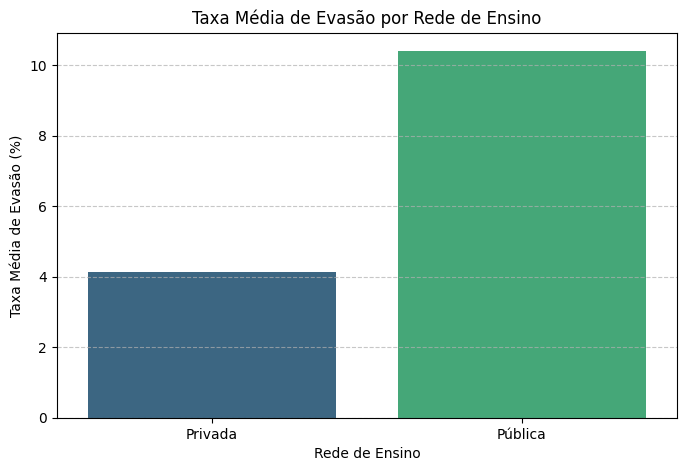

/tmp/ipykernel_2044/1820826798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Região', y='Taxa Média de Evasão', data=kpi_evasao_regiao, palette='magma')


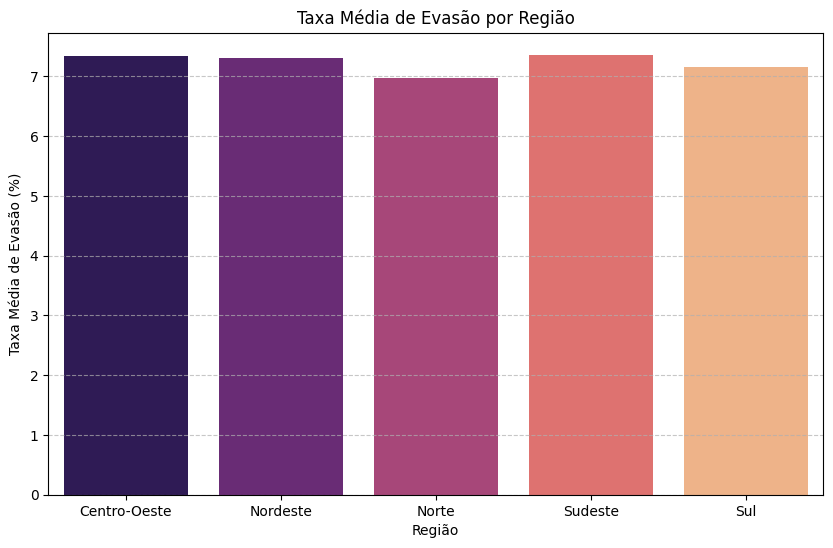

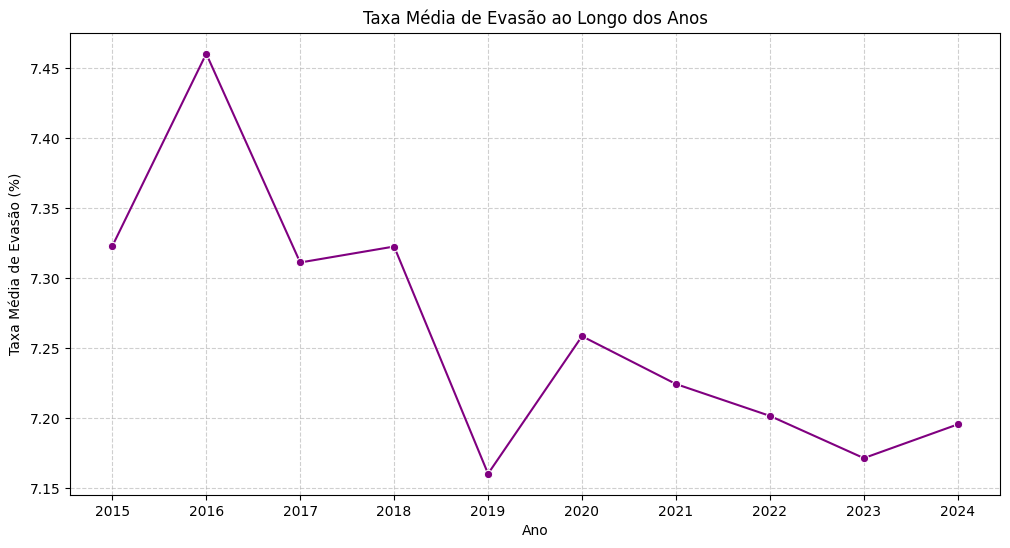

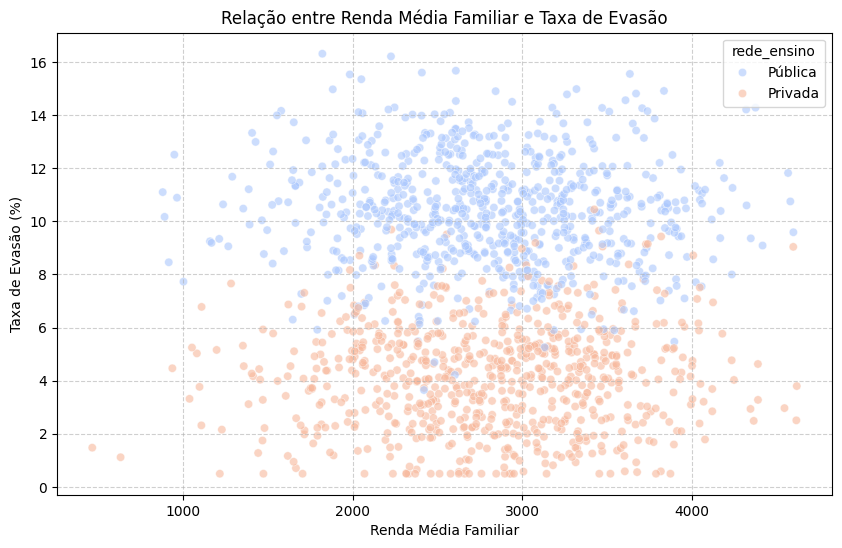

In [6]:
# Gráfico 1: Taxa Média de Evasão por Rede de Ensino
plt.figure(figsize=(8, 5))
sns.barplot(x='Rede de Ensino', y='Taxa Média de Evasão', data=kpi_evasao_rede, palette='viridis')
plt.title('Taxa Média de Evasão por Rede de Ensino')
plt.xlabel('Rede de Ensino')
plt.ylabel('Taxa Média de Evasão (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico 2: Taxa Média de Evasão por Região
plt.figure(figsize=(10, 6))
sns.barplot(x='Região', y='Taxa Média de Evasão', data=kpi_evasao_regiao, palette='magma')
plt.title('Taxa Média de Evasão por Região')
plt.xlabel('Região')
plt.ylabel('Taxa Média de Evasão (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico 3: Taxa de Evasão ao longo dos Anos
plt.figure(figsize=(12, 6))
sns.lineplot(x='ano', y='taxa_evasao', data=kpi_evasao_ano, marker='o', color='purple')
plt.title('Taxa Média de Evasão ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Taxa Média de Evasão (%)')
plt.xticks(kpi_evasao_ano['ano'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Gráfico 4: Relação entre Renda Média Familiar e Taxa de Evasão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda_media_familiar', y='taxa_evasao', data=df, alpha=0.6, hue='rede_ensino', palette='coolwarm')
plt.title('Relação entre Renda Média Familiar e Taxa de Evasão')
plt.xlabel('Renda Média Familiar')
plt.ylabel('Taxa de Evasão (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 9. Interpretação dos Resultados

Com base na análise exploratória de dados e nos KPIs calculados, podemos observar vários pontos importantes sobre a evasão escolar no dataset simulado:

*   **Taxa Média de Evasão:** A taxa média de evasão geral foi de aproximadamente 7.26%, o que indica um problema significativo que merece atenção.
*   **Rede de Ensino:** Existe uma diferença notável na taxa de evasão entre as redes de ensino. Escolas públicas (`Pública`) apresentam uma taxa de evasão média consideravelmente maior (aprox. 10.40%) em comparação com as escolas privadas (`Privada`) (aprox. 4.13%). Isso sugere que fatores relacionados à gestão, recursos ou perfil socioeconômico dos alunos em escolas públicas podem estar contribuindo para essa disparidade.
*   **Região:** As taxas de evasão por região são relativamente semelhantes, variando entre 6.98% (Norte) e 7.36% (Sudeste). Embora não haja grandes discrepâncias regionais neste dataset, pequenas variações podem ser observadas.
*   **Tendência Temporal:** A taxa de evasão ao longo dos anos mostra alguma flutuação. O ano de 2016 registrou a maior taxa média (7.46%), enquanto 2019 apresentou a menor (7.16%). Isso pode indicar que houve períodos com maior ou menor sucesso nas políticas de retenção ou que eventos específicos impactaram a evasão em certos anos.
*   **Renda e Desempenho:** A análise de correlação e o gráfico de dispersão podem indicar relações entre a renda familiar, o índice de desempenho e a taxa de evasão. Geralmente, esperaria-se que menor renda e menor desempenho estivessem associados a maiores taxas de evasão, o que a feature `renda_x_desempenho` tenta capturar. A análise mais aprofundada pode revelar a força e a direção dessas relações.
*   **Acesso à Internet:** O acesso à internet é uma variável importante, especialmente no contexto educacional moderno. Sua correlação com a taxa de evasão pode ser explorada para entender se a falta de conectividade contribui para a evasão.
*   **Nível de Risco:** A categorização de 'nivel_risco' e a criação da feature `is_alto_risco` permitem analisar se os alunos classificados com alto risco de evasão realmente apresentam taxas mais elevadas, validando a importância dessa classificação.

## 10. Conclusão

Este notebook realizou uma análise inicial robusta sobre um dataset simulado de evasão escolar no Brasil. Identificamos que a rede de ensino é um fator crítico, com escolas públicas enfrentando desafios significativamente maiores na retenção de alunos. Embora as variações regionais e temporais sejam menos pronunciadas neste conjunto de dados, elas ainda oferecem insights sobre a dinâmica da evasão. As novas features criadas, como `mes`, `trimestre`, `renda_x_desempenho` e `is_alto_risco`, são valiosas para futuras análises preditivas.

Para aprofundar a compreensão, recomenda-se:

1.  **Modelagem Preditiva:** Utilizar algoritmos de Machine Learning para prever a evasão com base nas características dos alunos e escolas, identificando os fatores de maior impacto.
2.  **Análise de Causa Raiz:** Realizar estudos qualitativos e quantitativos para entender as razões por trás da maior evasão em escolas públicas e em regiões ou períodos específicos.
3.  **Propostas de Intervenção:** Desenvolver e testar intervenções focadas nos grupos de maior risco, como programas de apoio pedagógico, suporte socioemocional ou iniciativas para melhorar o acesso à internet e recursos educacionais.

Em suma, a evasão escolar é um problema multifacetado que exige uma abordagem integrada. A análise de dados, como a realizada neste notebook, é fundamental para direcionar esforços e recursos de forma eficaz na busca por soluções.